In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import time
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, recall_score
from sklearn.metrics import precision_score
import joblib

def calculate_vpd(temperature, humidity):
    """Calculate Vapor Pressure Deficit (VPD) given temperature (°C) and relative humidity (%)."""
    es = 0.6108 * np.exp((17.27 * temperature) / (temperature + 237.3)) 
    ea = es * (humidity / 100.0)
    vpd = es - ea
    return vpd

In [2]:
# Load datasets
climate_df = pd.read_csv('GreenhouseClimate.csv', low_memory=False)
weather_df = pd.read_csv('Weather.csv', low_memory=False)
grodan_df = pd.read_csv('GrodanSens.csv', low_memory=False)

# Merge on time
merged_df = pd.merge(climate_df, weather_df, on='%time', how='inner')
full_df = pd.merge(merged_df, grodan_df, on='%time', how='inner')
print(f"Hợp nhất thành công! Kích thước: {full_df.shape}")

# Convert time column
full_df['datetime'] = pd.to_datetime(full_df['%time'], unit='D', origin='1899-12-30')
full_df.set_index('datetime', inplace=True)
full_df.drop('%time', axis=1, inplace=True)

Hợp nhất thành công! Kích thước: (47809, 66)


In [3]:
env_features = [
    # Từ GreenhouseClimate
    'Tair', 'Rhair', 'CO2air', 'HumDef', 'PipeGrow', 'PipeLow', 'Tot_PAR',
    # Từ Weather
    'Tout', 'Rhout', 'Iglob', 'Windsp', 'RadSum', 'Rain', 'PARout', 'Pyrgeo', 'AbsHumOut',
    # Từ GrodanSens
    'EC_slab1', 'EC_slab2', 'WC_slab1', 'WC_slab2', 't_slab1', 't_slab2',
    # Cột target
    'Cum_irr'
]
print(f"  - Giữ lại {len(env_features)} cột môi trường và cột target.")
clean_df = full_df[env_features].copy()


  - Giữ lại 23 cột môi trường và cột target.


In [4]:
for col in clean_df.columns:
    clean_df[col] = pd.to_numeric(clean_df[col], errors='coerce')
print("  - Chuyển đổi sang kiểu số hoàn tất.")
clean_df.dropna(subset=env_features[:-1], inplace=True) 
print(f"  - Số dòng SAU khi loại bỏ NaN: {len(clean_df)}")

  - Chuyển đổi sang kiểu số hoàn tất.
  - Số dòng SAU khi loại bỏ NaN: 45460


In [5]:
clean_df['VPD'] = calculate_vpd(clean_df['Tair'], clean_df['Rhair'])
clean_df['hour'] = clean_df.index.hour

WINDOW_SIZE_30M = 6  # 30 minutes

clean_df['Tair_30m_avg'] = clean_df['Tair'].rolling(window=WINDOW_SIZE_30M).mean()
clean_df['Iglob_30m_sum'] = clean_df['Iglob'].rolling(window=WINDOW_SIZE_30M).sum()
clean_df['WC_slab1_30m_ago'] = clean_df['WC_slab1'].shift(WINDOW_SIZE_30M)
clean_df['Tair_30m_diff'] = clean_df['Tair'].diff(WINDOW_SIZE_30M)

clean_df['PAR_x_HumDef'] = clean_df['Tot_PAR'] * clean_df['HumDef']
clean_df['Tair_x_Iglob'] = clean_df['Tair'] * clean_df['Iglob']

print(" - Feature Engineering complete (PartOfDay removed).")

clean_df.dropna(inplace=True)

 - Feature Engineering complete (PartOfDay removed).


In [6]:
# XÁC ĐỊNH BIẾN MỤC TIÊU VÀ RESAMPLE (3-HOUR CYCLE)

# 1. Dọn dẹp và nội suy cột Cumulative Irrigation
clean_df['Cum_irr'] = pd.to_numeric(clean_df['Cum_irr'], errors='coerce')
clean_df['Cum_irr'].interpolate(method='time', inplace=True)
clean_df['Cum_irr'].fillna(method='ffill', inplace=True)

# 2. TÍNH TOÁN LƯỢNG NƯỚC THỰC TẾ (5-min interval)
raw_water_diff = clean_df['Cum_irr'].diff()

# Giữ lại giá trị dương, đặt âm thành 0
clean_df['Watering_Amount'] = np.where(raw_water_diff > 0, raw_water_diff, 0)

# Xóa cột cũ không cần thiết
clean_df.drop('Cum_irr', axis=1, inplace=True)
clean_df = clean_df.iloc[1:].copy() 

print("\n--- ĐANG CHUYỂN ĐỔI SANG CHU KỲ 3 GIỜ (RESAMPLING) ---")

# 3. ĐỊNH NGHĨA CÁCH GỘP DỮ LIỆU
# - Target ('Watering_Amount'): Cộng tổng lượng nước trong 3 giờ.
# - Features (Tair, VPD, etc.): Lấy giá trị CUỐI CÙNG (Last) của chu kỳ.
#   (Vì giá trị cuối cùng chứa 'Tair_30m_avg' - tức là trung bình 30p lúc máy thức)

conversion_dict = {
    'Watering_Amount': 'sum'
}

# Tất cả các cột còn lại (features) sẽ dùng 'last'
input_features = [c for c in clean_df.columns if c != 'Watering_Amount']
for col in input_features:
    conversion_dict[col] = 'last'

# 4. THỰC HIỆN RESAMPLE
df_3h = clean_df.resample('3H').agg(conversion_dict)

# Loại bỏ các dòng bị NaN sau khi gộp (nếu có)
df_3h.dropna(inplace=True)

print(f"✅ Đã chuyển đổi xong!")
print(f" - Dữ liệu gốc (5 phút): {clean_df.shape}")
print(f" - Dữ liệu mới (3 giờ):   {df_3h.shape}")

print("\nPhân bố của biến mục tiêu (3-Hour Regression):")
print(df_3h['Watering_Amount'].describe()) 



--- ĐANG CHUYỂN ĐỔI SANG CHU KỲ 3 GIỜ (RESAMPLING) ---
✅ Đã chuyển đổi xong!
 - Dữ liệu gốc (5 phút): (45453, 31)
 - Dữ liệu mới (3 giờ):   (1273, 31)

Phân bố của biến mục tiêu (3-Hour Regression):
count    1273.000000
mean        0.555852
std         0.757841
min         0.000000
25%         0.000000
50%         0.300000
75%         0.800000
max         5.400000
Name: Watering_Amount, dtype: float64


/tmp/ipykernel_322116/753863717.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  clean_df['Cum_irr'].interpolate(method='time', inplace=True)
/tmp/ipykernel_322116/753863717.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [7]:
print(df_3h.head())
print(f"\nKích thước cuối cùng: {df_3h.shape}")

df_3h.to_csv('processed_greenhouse_data_clean.csv')
print("\nĐã lưu vào file 'processed_greenhouse_data_clean.csv'")

                     Watering_Amount  Tair  Rhair  CO2air  HumDef  PipeGrow  \
datetime                                                                      
2019-12-17 09:00:00              0.0  21.6   70.1   818.0     5.7       0.0   
2019-12-17 12:00:00              0.0  21.4   70.6   669.0     5.5       0.0   
2019-12-17 15:00:00              0.0  20.9   69.3   592.0     5.6       0.0   
2019-12-17 18:00:00              0.0  13.2   76.5   435.0     2.7       0.0   
2019-12-17 21:00:00              0.0  12.8   81.2   471.0     2.1       0.0   

                     PipeLow  Tot_PAR  Tout  Rhout  ...  t_slab1  t_slab2  \
datetime                                            ...                     
2019-12-17 09:00:00     39.4    126.0  12.0   80.9  ...     18.3     18.3   
2019-12-17 12:00:00      0.0    126.0  13.7   75.6  ...     20.3     20.4   
2019-12-17 15:00:00     41.3    149.0  10.4   95.4  ...     20.6     20.7   
2019-12-17 18:00:00      0.0      0.0   7.5   99.5  ...     1

In [8]:
print("\n Bắt đầu chuẩn bị dữ liệu huấn luyện (Regression)...")

df_3h = pd.read_csv('processed_greenhouse_data_clean.csv', index_col='datetime', parse_dates=True)
print(f" - Kích thước bộ dữ liệu đã tải: {df_3h.shape}")

y = df_3h['Watering_Amount']
X = df_3h.drop('Watering_Amount', axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"  - Kích thước tập Train: {X_train.shape}")
print(f"  - Kích thước tập Test: {X_test.shape}")


 Bắt đầu chuẩn bị dữ liệu huấn luyện (Regression)...
 - Kích thước bộ dữ liệu đã tải: (1273, 31)
  - Kích thước tập Train: (1018, 30)
  - Kích thước tập Test: (255, 30)


In [9]:
# These were deemed irrelevant by the LGBM model.
features_to_kill = [
    'hour', 'Iglob', 'PAR_x_HumDef', 't_slab1', 'VPD', 'CO2air', 'PipeLow', 'EC_slab2', 'HumDef', 'Tair_30m_diff', 'Windsp', 't_slab2', 'Pyrgeo', 'EC_slab1', 'Tout', 'Tair_30m_avg', 'AbsHumOut', 'Rhout', 'Rain'
]

# Assuming X_train and X_test are loaded from the previous split block:
X_train = X_train.drop(columns=features_to_kill, errors='ignore')
X_test = X_test.drop(columns=features_to_kill, errors='ignore')

print("\n--- Feature Pruning Complete ---")
print(f"🔪 Đã loại bỏ {len(features_to_kill)} features khỏi tập Train/Test.")
print(f"➡️ Số lượng Features Mới: {X_train.shape[1]}")


--- Feature Pruning Complete ---
🔪 Đã loại bỏ 19 features khỏi tập Train/Test.
➡️ Số lượng Features Mới: 11


In [10]:
lgb_reg = lgb.LGBMRegressor(
    objective='regression',
    metric='rmse',
    n_estimators=100,         # Reduced from 700
    learning_rate=0.025,       # Increased slightly
    num_leaves=15,            # Simpler trees
    max_depth=5,              # Reduced from 20
    min_child_samples=10,     # Ensure leaves have enough data
    # --------------------------
    random_state=42,
    n_jobs=-1,
    reg_alpha=0.1,            # Reduced regularization slightly
    colsample_bytree=0.8
)

start_time = time.time()
lgb_reg.fit(X_train, y_train)
end_time = time.time()

print(f"\nTinh chỉnh hoàn tất trong {(end_time - start_time):.2f} giây.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011173 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1898
[LightGBM] [Info] Number of data points in the train set: 1018, number of used features: 11
[LightGBM] [Info] Start training from score 0.490275

Tinh chỉnh hoàn tất trong 0.06 giây.


In [11]:
# Evaluate model

print("\n--- Đánh giá mô hình trên tập Test (Tương lai) ---")

# 1. Dự đoán
y_pred = lgb_reg.predict(X_test)

# 2. Ép các giá trị âm về 0 (Mô hình hồi quy đôi khi dự đoán -0.01)
y_pred = np.maximum(y_pred, 0)

# 3. Metrics Hồi quy (Độ chính xác về lượng nước)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📉 RMSE (Sai số bình phương trung bình): {rmse:.4f}")
print(f"📉 MAE (Sai số tuyệt đối trung bình):  {mae:.4f}")
print(f"📊 R2 Score (Độ phù hợp): {r2:.4f}")

# 4. CHECK RECALL (Kiểm tra an toàn)
# Nếu thực tế cần > 0.1 đơn vị nước, mà model dự đoán > 0.1, thì là ĐÚNG.
threshold = 0.1 

y_test_binary = (y_test > threshold).astype(int)
y_pred_binary = (y_pred > threshold).astype(int)

recall = recall_score(y_test_binary, y_pred_binary)
precision = precision_score(y_test_binary, y_pred_binary)

print(f"\n--- Kiểm tra an toàn (Classification Proxy) ---")
print(f"🛡️ RECALL (Độ nhạy - Quan trọng nhất): {recall:.4f}")
print(f"🎯 PRECISION (Độ chính xác khi tưới):  {precision:.4f}")


--- Đánh giá mô hình trên tập Test (Tương lai) ---
📉 RMSE (Sai số bình phương trung bình): 0.5752
📉 MAE (Sai số tuyệt đối trung bình):  0.3776
📊 R2 Score (Độ phù hợp): 0.6057

--- Kiểm tra an toàn (Classification Proxy) ---
🛡️ RECALL (Độ nhạy - Quan trọng nhất): 1.0000
🎯 PRECISION (Độ chính xác khi tưới):  0.7230


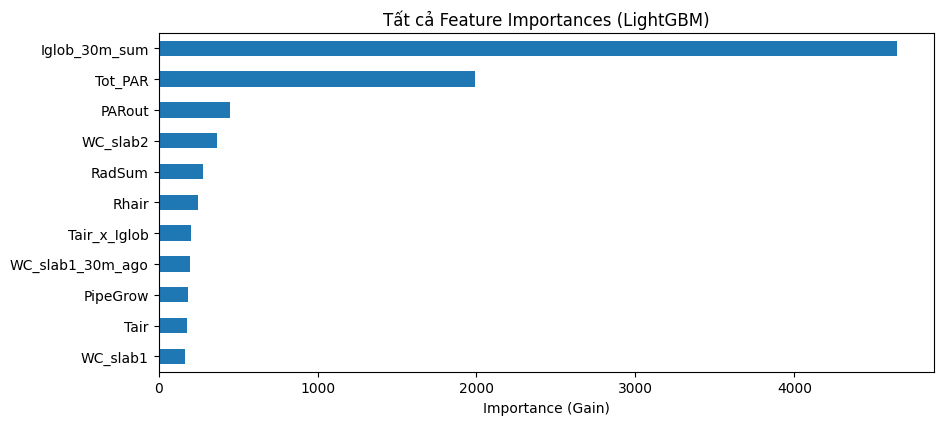

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Chú ý: Lấy feature importance từ booster object và sử dụng 'gain'
feat_importances = pd.Series(lgb_reg.booster_.feature_importance(importance_type='gain'), 
                             index=X_train.columns)

# Loại bỏ giới hạn [:14] để hiển thị TẤT CẢ features
feat_importances = feat_importances.sort_values(ascending=False)

# Điều chỉnh kích thước figure theo số lượng features để dễ đọc
plt.figure(figsize=(10, len(X_train.columns) * 0.4)) 

feat_importances.plot(kind='barh')
plt.gca().invert_yaxis() # Đảo ngược trục Y để feature quan trọng nhất ở trên
plt.title("Tất cả Feature Importances (LightGBM)")
plt.xlabel("Importance (Gain)")
plt.show()

In [13]:
import pandas as pd
import numpy as np

print("\n===== ANALYZING FEATURE IMPORTANCE FOR PRUNING =====")

# 1. Get feature names and importance scores (using 'gain' is standard for LightGBM)
# Assume lgb_reg is your final trained model
importance = lgb_reg.booster_.feature_importance(importance_type='gain')
features = lgb_reg.booster_.feature_name()

# 2. Create a DataFrame for visualization and filtering
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

# 3. Filter for features with importance LESS THAN 400
# Sort to clearly see which features just missed the cut.
features_to_drop_df = importance_df[importance_df['Importance'] < 100].sort_values(
    by='Importance', ascending=False
)

# 4. Extract the list of feature names
features_to_kill_list = features_to_drop_df['Feature'].tolist()

# 5. Display the results and the ready-to-copy list
print(f"Total features analyzed: {len(features)}")
print("\n--- FEATURES TO DROP ---")
print(features_to_drop_df.to_string(index=False))

print(f"\n💡 Total features recommended for removal: {len(features_to_kill_list)}")

# --- READY TO COPY KILL LIST ---
print("\n✂️ COPY THIS LIST FOR PRUNING: ✂️")
# This line generates the final, ready-to-paste Python list representation
print(str(features_to_kill_list))


===== ANALYZING FEATURE IMPORTANCE FOR PRUNING =====
Total features analyzed: 11

--- FEATURES TO DROP ---
Empty DataFrame
Columns: [Feature, Importance]
Index: []

💡 Total features recommended for removal: 0

✂️ COPY THIS LIST FOR PRUNING: ✂️
[]


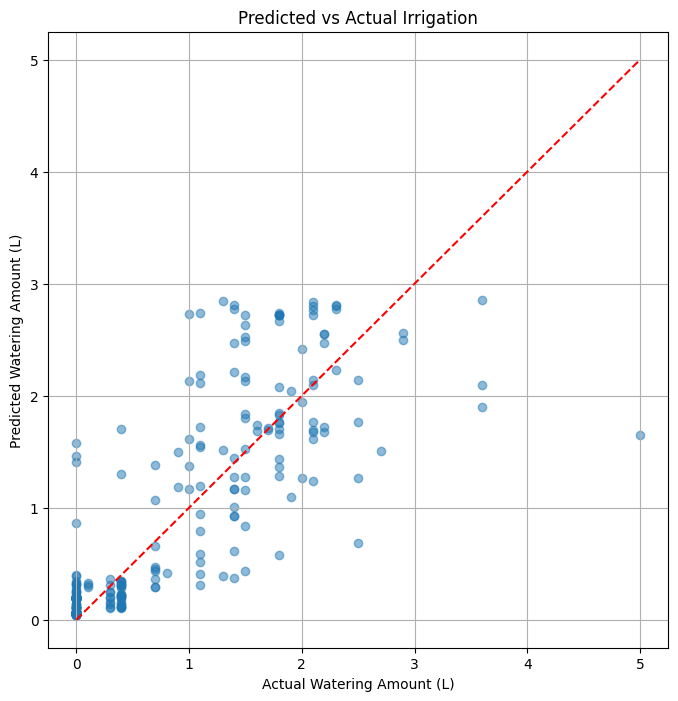

In [14]:
# Scatter plot of predicted vs. actual irrigation volumes for the test set. The red dashed line indicates perfect prediction.

plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--')  # Ideal line
plt.xlabel("Actual Watering Amount (L)")
plt.ylabel("Predicted Watering Amount (L)")
plt.title("Predicted vs Actual Irrigation")
plt.grid(True)
plt.show()


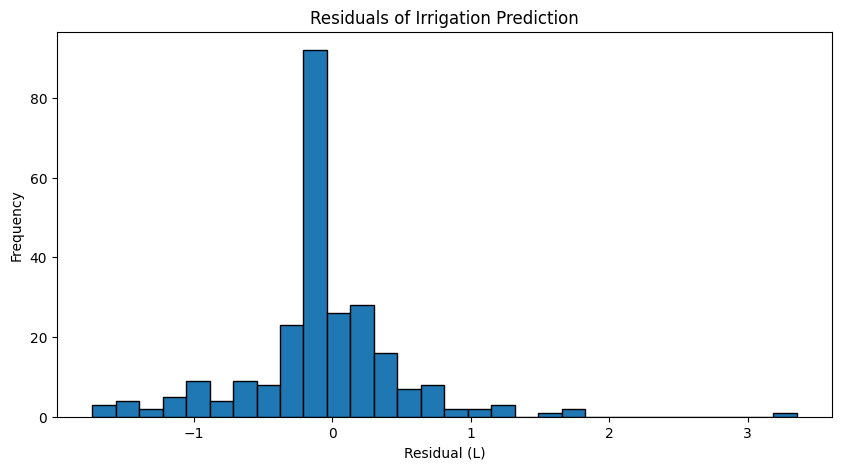

In [15]:
# Histogram of prediction residuals. Most predictions are close to zero error, indicating a good fit.

residuals = y_test - y_pred
plt.figure(figsize=(10,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residuals of Irrigation Prediction")
plt.xlabel("Residual (L)")
plt.ylabel("Frequency")
plt.show()


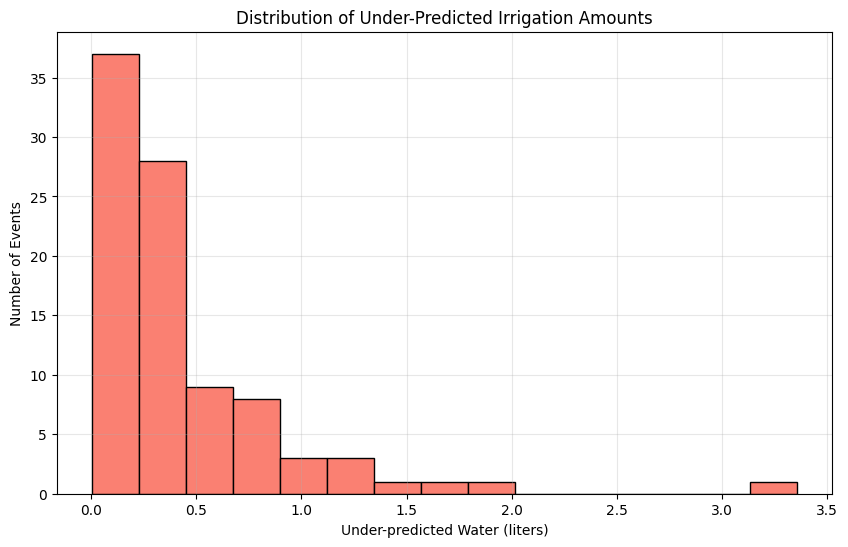

In [16]:
# Distribution of Under-Predicted Irrigation Amounts

under_pred_amounts = y_test[y_pred < y_test] - y_pred[y_pred < y_test]

plt.figure(figsize=(10,6))
plt.hist(under_pred_amounts, bins=15, color='salmon', edgecolor='black')
plt.title("Distribution of Under-Predicted Irrigation Amounts")
plt.xlabel("Under-predicted Water (liters)")
plt.ylabel("Number of Events")
plt.grid(alpha=0.3)
plt.show()


In [17]:
# ===============================================
# AVERAGE WATERING AMOUNT (Actual vs Predicted)
# ===============================================

# Actual average irrigation (3-hour cycle)
actual_avg = y_test.mean()

# Predicted average irrigation (3-hour cycle)
pred_avg = y_pred.mean()

print(f"Average actual watering amount:    {actual_avg:.3f} L per 3-hour cycle")
print(f"Average predicted watering amount: {pred_avg:.3f} L per 3-hour cycle")


Average actual watering amount:    0.818 L per 3-hour cycle
Average predicted watering amount: 0.888 L per 3-hour cycle


In [18]:
import joblib

model_filename = 'irrigation_regressor.joblib' 

joblib.dump(lgb_reg, model_filename)

print(f"✅ Model saved to: {model_filename}")

✅ Model saved to: irrigation_regressor.joblib


In [19]:
import sys
import os
import joblib

print("\n===== MODEL WEIGHT CHECK =====")

# 1. CHECK STORAGE/RAM WEIGHT (Serialized Size)
temp_file = 'temp_model_check.joblib'
joblib.dump(lgb_reg, temp_file)
size_bytes = os.path.getsize(temp_file)
size_kb = size_bytes / 1024
os.remove(temp_file) # Clean up

print(f"💾 Physical Size: {size_kb:.2f} KB")
print(f"   (This is roughly how much Flash memory it might take)")

# 2. CHECK COMPUTATIONAL WEIGHT (Complexity)
booster = lgb_reg.booster_
num_trees = booster.num_trees()
print(f"🌳 Number of Trees: {num_trees}")

# Estimate C-Code size
# A rough rule of thumb: 1 Tree ~= 1.5 KB of C code source text
est_c_size = num_trees * 1.5
print(f"📝 Estimated C-Code Source Size: ~{est_c_size:.0f} KB")

if size_kb > 1000:
    print("⚠️ WARNING: Model is heavy (>1MB). Might need partition resizing on ESP32.")
else:
    print("✅ GREEN: Model is lightweight and safe for ESP32.")


===== MODEL WEIGHT CHECK =====
💾 Physical Size: 150.15 KB
   (This is roughly how much Flash memory it might take)
🌳 Number of Trees: 100
📝 Estimated C-Code Source Size: ~150 KB
✅ GREEN: Model is lightweight and safe for ESP32.


In [20]:
print("\n--- Columns in the training set (Pruned) ---")
# This variable confirms the drop operation worked!
print(list(X_train.columns))

print(f"\nFinal Input Vector Length: {X_train.shape[1]}")


--- Columns in the training set (Pruned) ---
['Tair', 'Rhair', 'PipeGrow', 'Tot_PAR', 'RadSum', 'PARout', 'WC_slab1', 'WC_slab2', 'Iglob_30m_sum', 'WC_slab1_30m_ago', 'Tair_x_Iglob']

Final Input Vector Length: 11
